In [1]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from statistics import mean

from data_utils import *

In [2]:
label_cols = ["cohesion", "syntax", "vocabulary", "phraseology", "grammar", "conventions"]

df = pd.read_csv('../../input/feedback-prize-english-language-learning/train_fold.csv')

print(df.shape)
df.head()

(3911, 9)


,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,fold
0,0016926B079C,I think that students would benefit from learn...,3.5,3.5,3.0,3.0,4.0,3.0,2
1,0022683E9EA5,When a problem is a change you have to let it ...,2.5,2.5,3.0,2.0,2.0,2.5,0
2,00299B378633,"Dear, Principal\n\nIf u change the school poli...",3.0,3.5,3.0,3.0,3.0,2.5,1
3,003885A45F42,The best time in life is when you become yours...,4.5,4.5,4.5,4.5,4.0,5.0,3
4,0049B1DF5CCC,Small act of kindness can impact in other peop...,2.5,3.0,3.0,3.0,2.5,2.5,3


In [3]:
# df['full_text'] = df['full_text'].apply(lambda x : resolve_encodings_and_normalize(x))
# df['full_text'] = df['full_text'].apply(lambda x : preprocessing(x))
# df.head()

In [4]:
# df['cohesion'] = df['cohesion'].astype(str)

In [5]:
df['\r'] = df['full_text'].apply(lambda x: 1 if '\t' in x else 0)
df['\n'] = df['full_text'].apply(lambda x: 1 if '\n' in x else 0)
df['\r\n'] = df['full_text'].apply(lambda x: 1 if "\r\n" in x else 0)
df['\n\n'] = df['full_text'].apply(lambda x: 1 if "\n\n" in x else 0)

In [71]:
df['\n count'] = df['full_text'].apply(lambda x: sum(x.count(n) for n in ("\n\n", "\r", ";", ",")))
df['u count'] = df['full_text'].apply(lambda x: sum(1 for elem in x if elem.isupper()))
df['count'] = df['full_text'].apply(lambda x: sum(x.count(n) for n in (".")))

In [72]:
df['count'].unique()

array([18, 14, 19, 36,  3, 15, 22, 23, 10,  5, 25, 39,  6,  9, 13, 20, 12,
       16, 40,  8, 29, 11, 35, 28,  1, 31, 56,  4, 38, 46, 17, 27, 49, 26,
        7, 30, 24, 45, 33, 44,  2, 21, 37, 32, 41, 99, 34, 47, 55, 69,  0,
       43, 50, 42, 70, 54, 52, 51, 90, 58, 63, 48, 75, 57, 62, 53, 67, 65,
       59])

In [70]:
df[(df['u count'] > 1000)]['full_text'].values

array(["FIRST, I CHOOSE TOHAVE THE LONGER SPRING BREAKS.SECOND ,THE STUDENT CAN TRAVEL TO VISIT THEIR FAMILY.THIRD, ENJOYA THE BEACH FOR TIME THAT STUDENTS WANTS.DOESN'T HAVE WORRY ABOUT GOING BACK TO SCHOOL.\n\nFIRST I CHOSE THAT STUDENTS SHOULD HAVE LONGER BREAK BECAUSE THE STUDENT NEED TO FUN FOR THE BREAK . II CHOSE THAT STUDENT HAVE THE LONGER SUMMER BREAK BECAUSE THE IS MY FAVORITE BREAK IN MY ALL FAMILY STAY HOME OR SOMETIME WE ARE TRAVEL SOME ANOTHER COUNTRY .\n\nTHE MOST OF THE STUDENT TRAVEL FOR ANOTHER PLACE .THE SOME STUDENTS CAN TRAVEL TO VISIT THEIR FAMILY BECAUSE THERE FAMILY WAS A DIFFERNT COUNTRY OR DIFFERENT PLACE .WE ARE VISIT HOME BECAUSE WE ARE ENJOYA THEIR FAMILY.WE ARE TRAVEL THE THE FUN PLACE BECAUSE MY FAMILY WAS A LOVE THERE .\n\nWE ARE TRAVEL THE BEACH WE ARE ENJOY THE BEACH FOR MY FAMILY OR MY FRIENDS BECAUSE MY FRIEND AND WE ARE PLAY THE SAND WE HAVE THE FUN .MY ALL FAMILY WAS GOING THERE WE HAVE FUN. I CHOSE TONOT HAVE LONGER SPRING BREAK BECAUSE WON'T CAT

In [65]:
print(df[df['conventions'] == 1.0]['u count'].sort_values().unique()) 
print(df[df['conventions'] == 1.5]['u count'].sort_values().unique()) 
print(df[df['conventions'] == 2.0]['u count'].sort_values().unique()) 
print(df[df['conventions'] == 4.5]['u count'].sort_values().unique())
print(df[df['conventions'] == 5.0]['u count'].sort_values().unique())

[ 0  1  2  6  8  9 18 19 25]
[ 0  2  3  6  7  8 10 12 15 19 28 39 49]
[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
   14   15   16   17   18   19   20   21   22   23   24   25   26   27
   28   29   30   31   32   33   34   35   36   37   38   39   40   41
   42   43   44   47   48   49   50   52   53   54   55   61   62   66
   70   75   76   78   81   85   90   94  124  209 1684]
[ 7 10 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
 34 35 36 37 38 39 41 43 44 45 46 47 50 51 54 55 56 59 64 65 72 76 80 98]
[14 16 23 24 27 30 31 34 35 36 40 41 47 50 54 61 65 66 72 76 82 98]


In [74]:
print(df[df['conventions'] == 1.0]['count'].sort_values().unique()) 
print(df[df['conventions'] == 1.5]['count'].sort_values().unique()) 
print(df[df['conventions'] == 2.0]['count'].sort_values().unique()) 
print(df[df['conventions'] == 3.0]['count'].sort_values().unique()) 
print(df[df['conventions'] == 4.5]['count'].sort_values().unique())
print(df[df['conventions'] == 5.0]['count'].sort_values().unique())

[ 0  1  2  3  6  7  8  9 10 13 21]
[ 0  1  2  4  5  7  9 10 13 15 21 34]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 34 35 36 38 39 44 46 51 53]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 49 51 52 53 54 56 57 62 65 90 99]
[ 4  7  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31
 32 33 34 35 37 38 39 40 41 44 45 55 56 58 69]
[14 16 17 20 22 24 25 27 28 30 31 36 37 42 43 45 51 55]


In [6]:
df[(df['\n\n'] == 1) & (df['cohesion'] == 1.0)]

,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,fold,\r,\n,\r\n,\n\n
39,03844422EA75,my name is Generic_Name and my story is about ...,1.0,1.0,2.0,2.0,1.5,1.0,0,0,1,0,1
952,48EA282A4EAF,some student offer distance learning as an opt...,1.0,1.0,1.0,1.0,1.0,1.0,1,0,1,0,1
1540,767533E12569,he is a good because they are the prescient an...,1.0,1.0,1.0,1.0,1.0,1.0,3,0,1,0,1
2989,D669349412FB,"He is a good thinking,but you see fast all fal...",1.0,1.5,2.0,2.0,2.0,1.5,1,0,1,0,1
3037,D93EC6A7E859,people who value his ideas came be a millonari...,1.0,1.5,2.0,2.0,1.5,1.5,0,0,1,0,1
3086,DB2EA5C4828F,"Technology is positive, because is the good po...",1.0,1.0,1.5,1.0,1.0,1.0,2,0,1,0,1
3342,E76B3F5205CD,Yes i am agrey life's is important and people ...,1.0,1.5,1.5,2.0,1.5,1.0,3,0,1,0,1


In [7]:
df[(df['\n\n'] == 0) & (df['\n'] == 1) & (df['\r\n'] == 0)]

,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,fold,\r,\n,\r\n,\n\n


In [8]:
df[(df['\r\n'] == 1) & (df['\r'] == 1)]

,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,fold,\r,\n,\r\n,\n\n
5,004AC288D833,"Dear Principal,\r\n\r\nOur school should have ...",3.5,4.0,4.0,3.5,3.5,4.0,2,1,1,1,0
40,038480498E5A,"Dear Principal,\r\n\r\nI think that it is a gr...",4.0,3.0,3.5,3.5,3.0,3.5,2,1,1,1,0
72,0563F089C239,To the principal:\r\n\r\nCell phone is a very ...,3.0,3.5,4.0,3.5,2.5,4.0,1,1,1,1,0
180,0DB44DDF91E6,Dear principal.\r\n\r\nWe like to clean litter...,3.0,3.0,3.0,2.5,3.0,3.0,0,1,1,1,0
212,0FF307182628,"Dear principal,\r\n\r\nI think that it is okay...",2.5,3.0,2.5,2.5,3.5,3.0,2,1,1,1,0
379,1CF3776F970D,"Dear principal,\r\n\r\nWell its important to h...",3.5,2.5,3.5,3.0,3.0,3.5,1,1,1,1,0
405,1EB4D8BFB732,Dear principal\r\n\r\nwhat are community servi...,3.0,3.5,4.0,4.0,3.5,3.0,1,1,1,1,0
416,1FACF7E8D0A7,Dear principal\r\n\r\nI do think that students...,3.5,3.5,3.0,3.5,3.5,3.5,3,1,1,1,0
454,223FCA37F79D,We should allow the students to bring there ce...,3.0,4.0,4.0,4.0,4.0,3.0,0,1,1,1,0
587,2C7750B811F3,"Dear Mr. Principal,\r\n\r\nMy name is STUDENT_...",3.0,3.0,4.0,3.0,2.5,3.5,3,1,1,1,0


In [9]:
df[df['\n\n'] == 1]

,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,fold,\r,\n,\r\n,\n\n
0,0016926B079C,I think that students would benefit from learn...,3.5,3.5,3.0,3.0,4.0,3.0,2,0,1,0,1
1,0022683E9EA5,When a problem is a change you have to let it ...,2.5,2.5,3.0,2.0,2.0,2.5,0,0,1,0,1
2,00299B378633,"Dear, Principal\n\nIf u change the school poli...",3.0,3.5,3.0,3.0,3.0,2.5,1,0,1,0,1
3,003885A45F42,The best time in life is when you become yours...,4.5,4.5,4.5,4.5,4.0,5.0,3,0,1,0,1
4,0049B1DF5CCC,Small act of kindness can impact in other peop...,2.5,3.0,3.0,3.0,2.5,2.5,3,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,FFCDB2524616,"I agree with Ralph Waldo Emerson's ""\n\nTo be ...",2.5,3.0,3.0,4.0,3.5,3.0,0,0,1,0,1
3906,FFD29828A873,I believe using cellphones in class for educat...,2.5,3.0,3.0,3.5,2.5,2.5,1,0,1,0,1
3907,FFD9A83B0849,"Working alone, students do not have to argue w...",4.0,4.0,4.0,4.0,3.5,3.0,1,0,1,0,1
3909,FFE16D704B16,Many people disagree with Albert Schweitzer's ...,4.0,4.5,4.5,4.0,4.5,4.5,2,0,1,0,1


In [10]:
df[df['cohesion'] == 1.0]

,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,fold,\r,\n,\r\n,\n\n
39,03844422EA75,my name is Generic_Name and my story is about ...,1.0,1.0,2.0,2.0,1.5,1.0,0,0,1,0,1
952,48EA282A4EAF,some student offer distance learning as an opt...,1.0,1.0,1.0,1.0,1.0,1.0,1,0,1,0,1
1161,59ADAA4D04E5,People who value self they have defrine indidu...,1.0,1.5,1.5,2.0,1.5,1.0,2,0,0,0,0
1540,767533E12569,he is a good because they are the prescient an...,1.0,1.0,1.0,1.0,1.0,1.0,3,0,1,0,1
2989,D669349412FB,"He is a good thinking,but you see fast all fal...",1.0,1.5,2.0,2.0,2.0,1.5,1,0,1,0,1
3037,D93EC6A7E859,people who value his ideas came be a millonari...,1.0,1.5,2.0,2.0,1.5,1.5,0,0,1,0,1
3086,DB2EA5C4828F,"Technology is positive, because is the good po...",1.0,1.0,1.5,1.0,1.0,1.0,2,0,1,0,1
3342,E76B3F5205CD,Yes i am agrey life's is important and people ...,1.0,1.5,1.5,2.0,1.5,1.0,3,0,1,0,1
3679,F69C85F4C3CA,the memorable teacher ever had\r\n\r\nwas a te...,1.0,1.0,1.5,1.0,1.0,1.5,2,1,1,1,0
3706,F7B655834981,she is not to bring a phones in school because...,1.0,1.5,1.5,1.5,2.0,2.0,2,0,0,0,0


In [11]:
df.loc[3706, 'full_text']

'she is not to bring a phones in school because it is the school and you do not a phones to you get in t and get at school you cult get call home and you get a big and you cum to for a mouth ,you we be other lunch .or you do not cum you we be achubll and i wuld call your mom to tell you to cum . and stop testing went you are tollking and you are going to get a teket stop testing well be stop you well be in a cold and you well be stop. you would stop .would be stop and you. do not have allo w students to have phoneat school at all.'

In [12]:
# df["stopword_count"] = df['full_text'].apply(lambda x : len([_ for _ in x if _.is_stop]))
df['word_count'] = df['full_text'].apply(lambda x: len(x.split()))
df['unique_word_count'] = df['full_text'].apply(lambda x: len(set(x.split())))
df["char_count"] = df['full_text'].apply(lambda x : mean([len(i) for i in x.split()]))

df['word_count'] = df['word_count'].apply(lambda x: x/df['word_count'].max())
df['unique_word_count'] = df['unique_word_count'].apply(lambda x: x/df['unique_word_count'].max())
df['char_count'] = df['char_count'].apply(lambda x: x/df['char_count'].max())

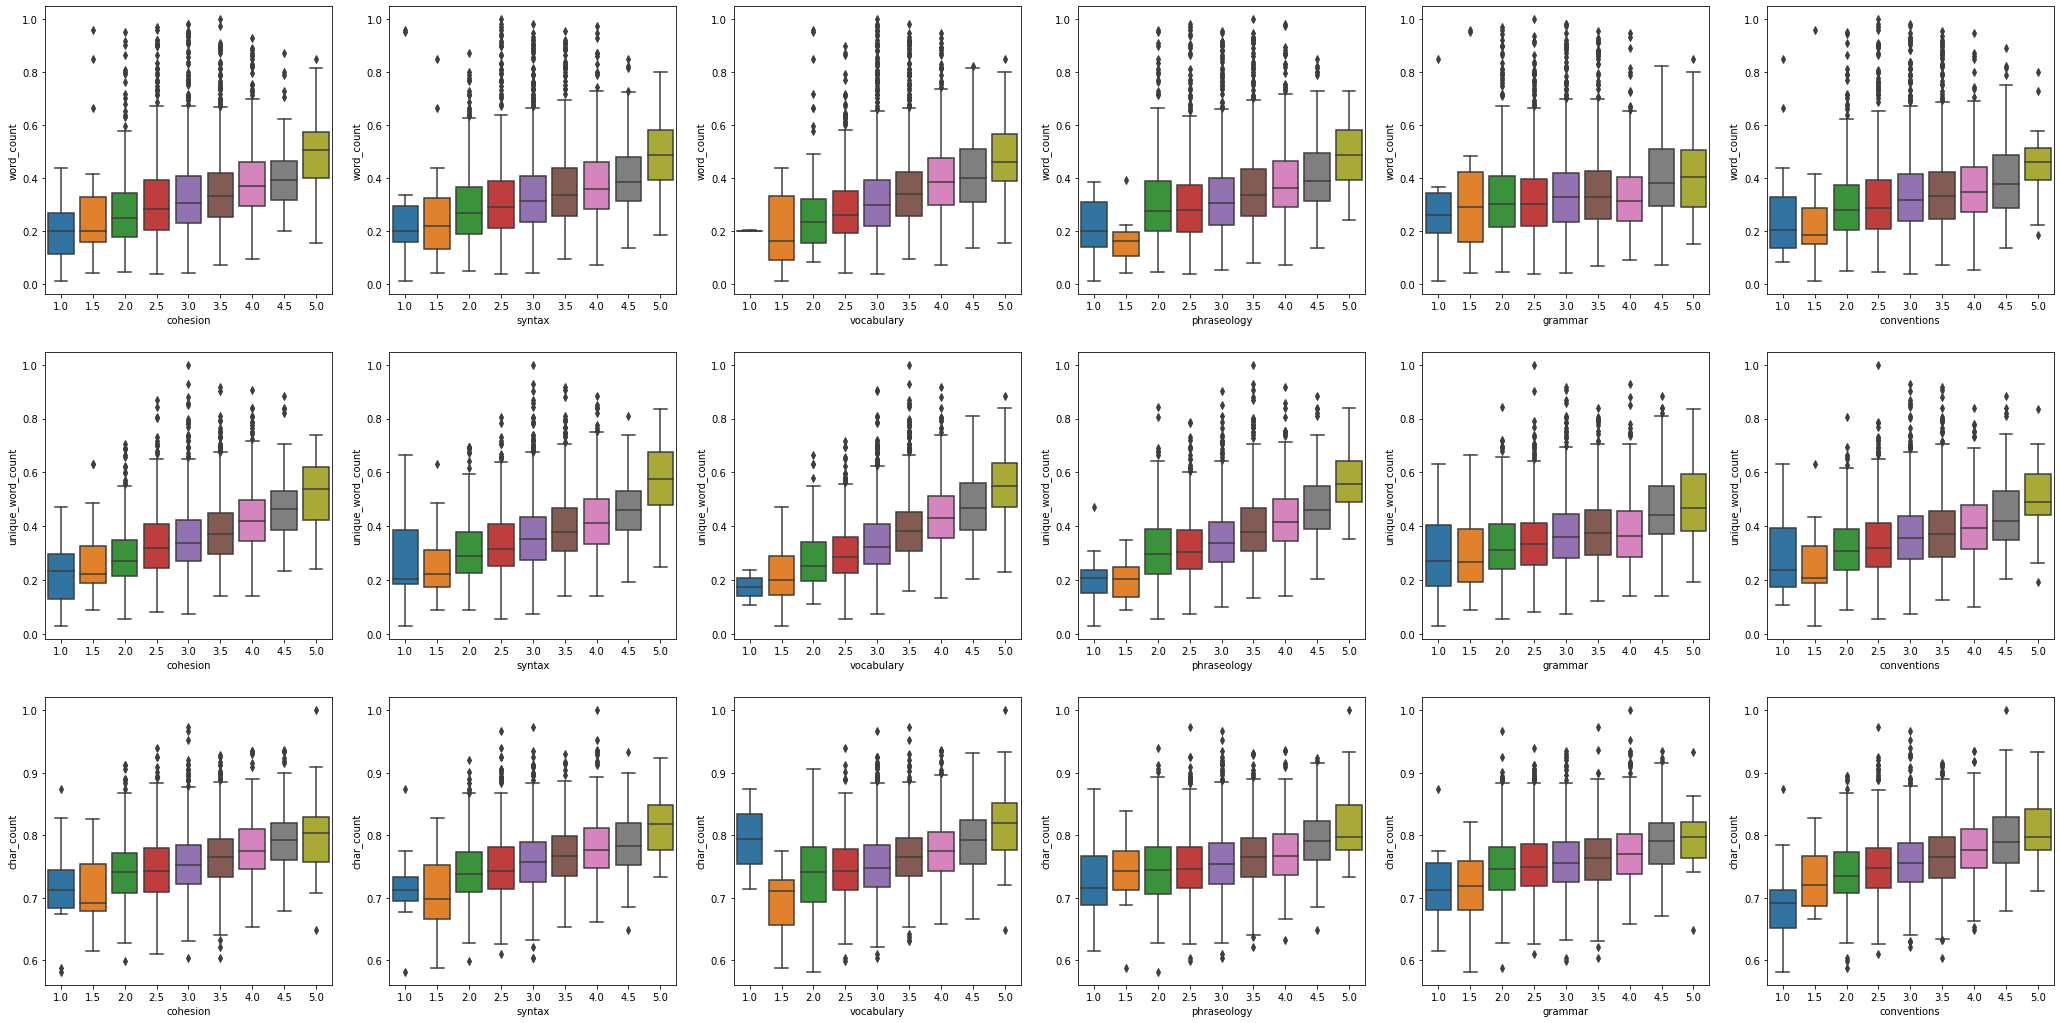

In [13]:
features = ["word_count", "unique_word_count", "char_count"]

rows= len(features)
cols = len(label_cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*6))

for row in range(rows):
    for col in range(cols):
        sns.boxplot(data=df, y=features[row], x=label_cols[col], ax=axes[row, col])

In [14]:
df[df['cohesion'] <= 1.5]

,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,fold,\r,\n,\r\n,\n\n,word_count,unique_word_count,char_count
39,03844422EA75,my name is Generic_Name and my story is about ...,1.0,1.0,2.0,2.0,1.5,1.0,0,0,1,0,1,0.248413,0.300000,0.581960
178,0D8EC8868869,Dou you think are you success or not? some peo...,1.5,2.0,1.5,1.5,2.0,1.5,1,0,1,0,1,0.162698,0.212766,0.705892
254,12796C5A0480,"Desagree,because to select yes the to taste to...",1.5,1.5,2.0,1.5,2.0,2.0,2,0,1,0,1,0.160317,0.223404,0.755356
378,1CE5DBCEF2CE,allow students to bring phones to school and w...,1.5,1.5,1.5,1.0,2.0,1.0,2,0,0,0,0,0.083333,0.142553,0.681586
424,202C217E354A,i think it is good because if we know what we ...,1.5,2.0,2.5,2.0,2.0,1.5,3,0,1,0,1,0.157143,0.187234,0.666335
514,2716F5E20A4F,"The students be required to take music ,drama ...",1.5,1.0,1.5,1.0,1.0,1.5,2,0,1,0,1,0.163492,0.200000,0.774666
680,346E77F08903,"My opinion is what, the student and doctor hav...",1.5,1.5,1.5,1.5,1.5,2.5,0,0,1,0,1,0.171429,0.202128,0.729081
934,4751F39ECBC5,thi don't really select a work in wat iam inte...,1.5,1.5,1.5,1.0,1.5,1.0,3,0,0,0,0,0.132540,0.182979,0.647528
952,48EA282A4EAF,some student offer distance learning as an opt...,1.0,1.0,1.0,1.0,1.0,1.0,1,0,1,0,1,0.202381,0.108511,0.873524
1161,59ADAA4D04E5,People who value self they have defrine indidu...,1.0,1.5,1.5,2.0,1.5,1.0,2,0,0,0,0,0.088095,0.155319,0.725140


In [15]:
df[df['syntax'] > 4.5]

,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,fold,\r,\n,\r\n,\n\n,word_count,unique_word_count,char_count
104,07CE77EA56C5,Students work hard there is no arguing that. T...,5.0,5.0,5.0,5.0,4.5,4.5,1,0,1,0,1,0.580159,0.674468,0.860534
143,0AFC8CE27321,"By the time students enter high school, I beli...",4.5,5.0,4.5,5.0,5.0,4.5,2,0,1,0,1,0.278571,0.351064,0.744784
258,12E3D52345C6,Technology has always acted as a compelling an...,5.0,5.0,5.0,5.0,4.5,5.0,1,0,1,0,1,0.516667,0.634043,0.909570
933,474D243CD03A,Every students expect that they are going to h...,5.0,5.0,4.0,4.0,4.5,4.5,1,0,1,0,1,0.544444,0.551064,0.765471
1060,5132328226C2,Afterschool Homework Club\n\nMost students do ...,5.0,5.0,5.0,5.0,4.5,4.5,2,0,1,0,1,0.604762,0.576596,0.847800
1082,52DC3B7C3952,Working From Home\n\nShould students be allowe...,5.0,5.0,4.5,5.0,5.0,5.0,0,0,1,0,1,0.403175,0.423404,0.769151
1203,5D5672D7C97D,"The famous scientist Albert Einstein said, ""Im...",4.5,5.0,5.0,4.5,4.5,5.0,1,0,1,0,1,0.463492,0.704255,0.923735
1206,5D7D1445A7CF,Smooth Sails do not make Skillful Sailors!\n\n...,4.5,5.0,5.0,5.0,4.5,4.5,2,0,1,0,1,0.567460,0.642553,0.777006
1308,649C7912163C,Have you ever thought of a place in the world ...,4.0,5.0,4.5,4.5,5.0,4.0,0,0,1,0,1,0.184127,0.246809,0.805508
1640,7CAFF57E1775,"Dear principal,\n\nI have heard of the school ...",4.5,5.0,5.0,4.5,5.0,4.0,3,0,1,0,1,0.354762,0.478723,0.825965


In [16]:
df[(df['cohesion'] > 3.0) & (df['cohesion'] < 4.0)]

,text_id,full_text,cohesion,syntax,vocabulary,phraseology,grammar,conventions,fold,\r,\n,\r\n,\n\n,word_count,unique_word_count,char_count
0,0016926B079C,I think that students would benefit from learn...,3.5,3.5,3.0,3.0,4.0,3.0,2,0,1,0,1,0.207143,0.306383,0.744165
5,004AC288D833,"Dear Principal,\r\n\r\nOur school should have ...",3.5,4.0,4.0,3.5,3.5,4.0,2,1,1,1,0,0.260317,0.270213,0.807146
6,005661280443,Imagine if you could prove other people that y...,3.5,4.0,3.5,3.5,4.0,4.0,3,0,1,0,1,0.342063,0.274468,0.764469
11,00BCADB373EF,A positive attitude is the key to success for ...,3.5,3.0,4.0,3.5,3.0,3.0,1,0,1,0,1,0.326984,0.414894,0.823082
12,00D281524375,Technology allows people to do many things suc...,3.5,2.5,3.5,3.0,3.0,3.0,0,0,1,0,1,0.159524,0.261702,0.758244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3894,FF76D397A73C,Not all the types of success have to be kind o...,3.5,3.0,3.0,3.5,2.5,2.5,0,0,1,0,1,0.308730,0.459574,0.744899
3895,FF7FE6BD8509,I agree that first impression is almost imposs...,3.5,3.5,3.5,3.5,3.5,3.5,0,0,1,0,1,0.493651,0.487234,0.751680
3899,FF9469424ED0,All schools have different educational activit...,3.5,3.5,4.5,3.5,4.0,4.0,2,0,1,0,1,0.509524,0.551064,0.793403
3901,FF9E0379CD98,Some school offer distence learning as a optio...,3.5,2.5,3.0,3.0,2.0,2.5,3,0,1,0,1,0.250000,0.259574,0.773242


In [17]:
df.loc[39, 'full_text']

'my name is Generic_Name and my story is about cars\n\nI bay a car and it new i live that car so mush so i stirt taking caer to it and befor I usto have a buskel and i usto love that baskel so mauh but i gat older so i stop riding a biskel and i stirt looking for a beges thengs whan i was a kid i usto so my dad driveng a car and i usto haveng fun in it\n\n;and my drimm was to bay a car win i gro up and i stil looking for that drimm seccer is the only sport i like i use to play seccer win i weas 11 years old and i stil play that geame and i love it so mush but my lieg get hert so i stop playing it any moer and then i stirt fling better so i want to go bake to play my favert game seccer so i try ot for school and i stirt making frinds and play with them my favert game evry day i even like a gril becoes that game so l like that gril and i stirt playing wiht her and taking wihe her and i wanted her number so i stirt beang cloes to her so it bean a year so i finly say it i told her that i l

In [18]:
df.loc[3602, 'full_text']

'Being yourself brings out the better you in a person. When you are yourself your a better person because your not changing yourself to be someone your not. Sometimes its good to change in your life but don\'t loose the way you are to be someone worse because your attitude and personality is what stands out the most in you. Most people change because they want to be a better person or they are tired of being so quiet and keep to themselves. The way someone is shows the kind of person you are and to try to change back to the person your not anymore could be difficult because you are changing your ways as a person.\n\nFirstly; being yourself means you are unique in your own way. You don\'t have to change yourself to prove a point to someone. No matter how mean, rude, disrespectful you are you can\'t really change the reason I say that is because that is how you are already as a person. Most changes can occur maybe from someone loosing another person like they passed away and it hurts you

In [19]:
df.loc[39, 'full_text']

'my name is Generic_Name and my story is about cars\n\nI bay a car and it new i live that car so mush so i stirt taking caer to it and befor I usto have a buskel and i usto love that baskel so mauh but i gat older so i stop riding a biskel and i stirt looking for a beges thengs whan i was a kid i usto so my dad driveng a car and i usto haveng fun in it\n\n;and my drimm was to bay a car win i gro up and i stil looking for that drimm seccer is the only sport i like i use to play seccer win i weas 11 years old and i stil play that geame and i love it so mush but my lieg get hert so i stop playing it any moer and then i stirt fling better so i want to go bake to play my favert game seccer so i try ot for school and i stirt making frinds and play with them my favert game evry day i even like a gril becoes that game so l like that gril and i stirt playing wiht her and taking wihe her and i wanted her number so i stirt beang cloes to her so it bean a year so i finly say it i told her that i l

In [20]:
preprocessing(df.loc[2540, 'full_text'])

'Dear. Principal, [R] I think the best and awesome policy is policy number 1 , because the students need their cell phones to call their family members to pick them up. I see a lot of students use there phones in class, but maybe if you give them other free times to use it they may not use it during class periods. Having to use phones in your own free time is not a bad idea, but need to remember to turned off their phones in class. [R] From: STUDENT_NAME [R] 2/28/11'